# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [41]:
df = pd.read_csv('heart.csv')  # adjust path
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [42]:
df.info()
df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1         2
29   1    1   130       204   0    0        202      0      0.0      2      0   2     1         1
34   1    3   118       182   0    0        174      0      0.0      2      0   2     1         1
     0    1   118       210   0    1        192      0      0.7      2      0   2     1         1
35   0    0   138       183   0    1        182      0      1.4      2      0   2     1         1
                                                                                               ..
71   0    0   112       149   0    1        125      0      1.6      1      0   2     1         1
          1   160       302   0    1        162      0      0.4      2      2   2     1         1
          2   110       265   1    0        130      0      0.0      2      1   2     1         1
74   0    1   120       2

Text(0.5, 1.0, 'Target Distribution')

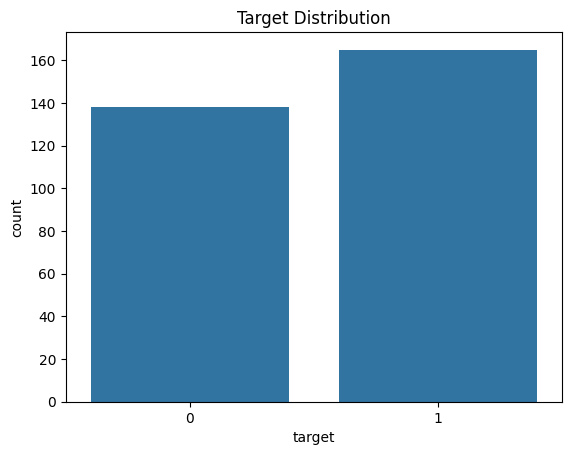

In [43]:
#class balance
sns.countplot(x='target', data=df)
print(df[df['target'] == 1].value_counts())
print(df[df['target'] == 0].value_counts())
plt.title("Target Distribution")
#balance is good, we have 138 samples of class 0 and 164 samples of class 1

<Axes: >

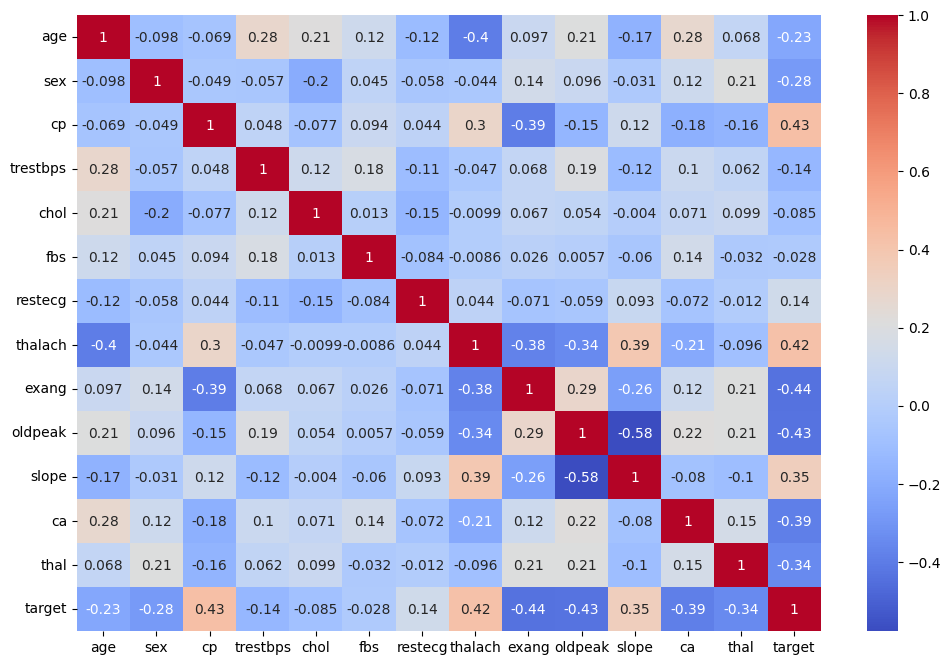

In [44]:
#correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
#no strong correlations, but some moderate ones like between age and target, and between cp and target.

<Axes: xlabel='target', ylabel='age'>

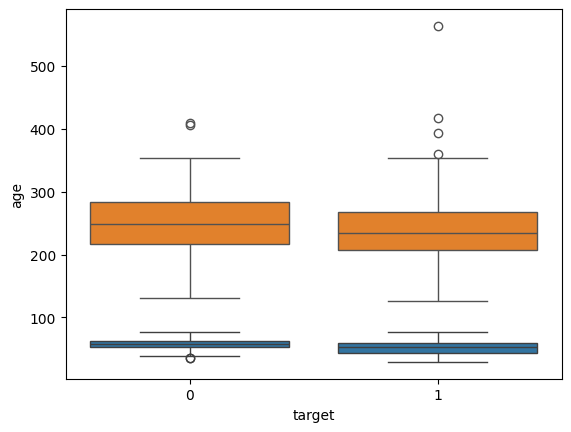

In [57]:
sns.boxplot(x='target', y='age', data=df)
sns.boxplot(x='target', y='chol', data=df)
#Some mild outliers exist but were not removed as logistic regression is not highly sensitive to them

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [46]:
X = df.drop('target', axis=1)
y = df['target']

**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [49]:
#baseline model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

### Coeffecients

**TASK: Report back the model's coefficients.**

In [50]:
model.coef_

array([[-0.07244537, -0.73459575,  0.89371356, -0.26249543, -0.21218597,
         0.04596441,  0.12036576,  0.43326353, -0.42823456, -0.52722504,
         0.38098131, -0.85080651, -0.57468743]])

In [79]:

"""  In this fitted model, cp has a positive coefficient, so higher cp values
 are associated with a higher predicted probability of heart disease.
 ca has a strong negative coefficient, so higher ca values are associated
 with a lower predicted probability in this model. """
pd.DataFrame(model.coef_[0], index=X.columns, columns=["Coefficient"])


,Coefficient
age,-0.072445
sex,-0.734596
cp,0.893714
trestbps,-0.262495
chol,-0.212186
fbs,0.045964
restecg,0.120366
thalach,0.433264
exang,-0.428235
oldpeak,-0.527225


## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

**for baseline model**

In [51]:

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8387096774193549

[[12  3]
 [ 2 14]]


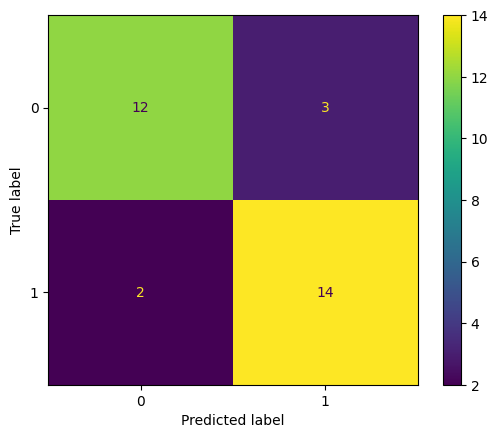

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



In [ ]:
#trying a custom threshold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []
# Based on threshold comparison, threshold = 0.7 gave the best overall accuracy and F1-score.
# Therefore, the final chosen setup is the default logistic regression model with decision threshold 0.7.
for t in [0.3, 0.5, 0.7]:
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred_t = (y_prob >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

pd.DataFrame(threshold_results)

,threshold,accuracy,precision,recall,f1
0,0.3,0.838710,0.789474,0.9375,0.857143
1,0.5,0.838710,0.823529,0.8750,0.848485
2,0.7,0.903226,0.933333,0.8750,0.903226


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

"""  All tested models produced the same test accuracy and F1-score.
 Therefore, the default logistic regression model was kept as the baseline model,
 since increasing/decreasing regularization or adding balanced class weights
 did not improve performance on this split. """

model_names = ["default", "C=0.1", "C=10", "class_weight=balanced"]

accuracies = []
f1_scores = []

for m in models:
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)

    accuracies.append(accuracy_score(y_test, pred))
    f1_scores.append(f1_score(y_test, pred))

model_results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies,
    "F1 Score": f1_scores
})

model_results



,Model,Accuracy,F1 Score
0,default,0.83871,0.848485
1,C=0.1,0.83871,0.848485
2,C=10,0.83871,0.848485
3,class_weight=balanced,0.83871,0.848485


### Performance Curves

**TASK: Create the ROC Curve.**

**For baselinemodel**


0.9625000000000001

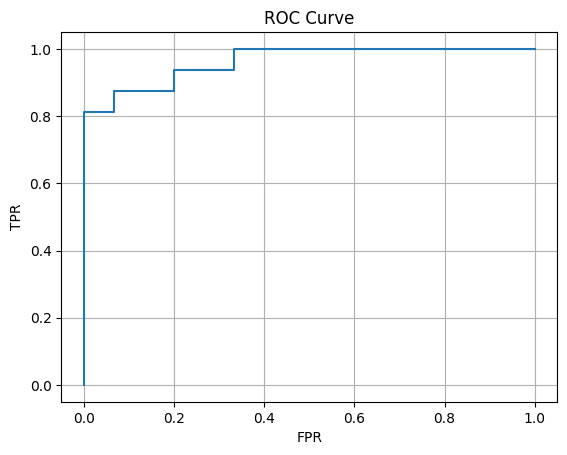

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.grid()

roc_auc_score(y_test, y_prob)

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [71]:
patient_df = pd.DataFrame([[48.0,0.0,2.0,130.0,275.0,0.0,1.0,139.0,0.0,0.2,2.0,0.0,2.0]],
                          columns=X.columns)

patient_scaled = scaler.transform(patient_df)
patient_prob = model.predict_proba(patient_scaled)[0,1]

best_threshold = 0.7
patient_pred = int(patient_prob >= best_threshold)

print("Predicted probability:", patient_prob)
print("Predicted class using threshold 0.7:", patient_pred)
"""  The model predicts class 1 (presence of heart disease).
 The predicted probability for heart disease is 0.9796 (~97.96%),
 which indicates very high confidence. """

Predicted probability: 0.9796347256499293
Predicted class using threshold 0.7: 1


'  The model predicts class 1 (presence of heart disease).\n The predicted probability for heart disease is 0.9796 (~97.96%),\n which indicates very high confidence. '

In [ ]:
# Final chosen setup
# same trained logistic regression model, but evaluated using the selected threshold 0.7
final_model = LogisticRegression()
final_model.fit(X_train_scaled, y_train)

y_prob_final = final_model.predict_proba(X_test_scaled)[:,1]
best_threshold = 0.7
y_pred_final = (y_prob_final >= best_threshold).astype(int)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("Final Classification Report:\n", classification_report(y_test, y_pred_final))

Final Accuracy: 0.9032258064516129
Final Confusion Matrix:
 [[14  1]
 [ 2 14]]
Final Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.93      0.88      0.90        16

    accuracy                           0.90        31
   macro avg       0.90      0.90      0.90        31
weighted avg       0.91      0.90      0.90        31

